# Analyzing Precipitation in Seattle and Charlotte

In [1]:
# Import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

## Load and explore dataset

### Seattle Data

In [2]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/binay8/weather/refs/heads/master/data/seattle_data.csv")

In [3]:
df_sea.head(10)

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/1/2018,0.00,0.0,0.0
1,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/2/2018,0.00,0.0,0.0
2,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/3/2018,0.00,0.0,0.0
3,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/4/2018,0.13,0.0,0.0
4,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/5/2018,0.51,0.0,0.0
5,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/6/2018,0.17,0.0,0.0
6,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/7/2018,0.33,0.0,0.0
7,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/8/2018,0.16,0.0,0.0
8,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/9/2018,0.18,0.0,0.0
9,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",1/10/2018,0.17,0.0,0.0


### Charlotte Data

In [4]:
df_cha = pd.read_csv("https://raw.githubusercontent.com/binay8/weather/refs/heads/master/data/charlotte_data.csv")

In [5]:
df_cha.head(10)

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/1/2018,0.00,0.0,0.0
1,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/2/2018,0.00,0.0,0.0
2,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/3/2018,0.00,0.0,0.0
3,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/4/2018,0.00,0.0,0.0
4,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/5/2018,0.00,0.0,0.0
5,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/6/2018,0.00,0.0,0.0
6,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/7/2018,0.00,0.0,0.0
7,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/8/2018,0.04,0.0,0.0
8,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/9/2018,0.00,0.0,0.0
9,USW00013881,"CHARLOTTE DOUGLAS AIRPORT, NC US",1/10/2018,0.00,0.0,0.0


### Review available columns for both datasets

In [6]:
df_sea.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='str')

In [7]:
df_cha.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='str')

### Using df.info() to review additional information about our data set
Looking for potential missing or incomplete data, review how many rows, data type, null values....

In [8]:
df_sea.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1823 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), str(3)
memory usage: 173.0 KB


Seattle's dataset is missing precipitation data in 3 rows.

In [9]:
df_cha.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), str(3)
memory usage: 178.4 KB


### Review Station Details
Ideally only one station per city.

In [10]:
print(df_sea['STATION'].unique())
print(df_cha['STATION'].unique())

<ArrowStringArray>
['USW00024233']
Length: 1, dtype: str
<ArrowStringArray>
['USW00013881']
Length: 1, dtype: str


## Start data cleanup/clense

Initial impression is that attributes Name and Stations is redudant. Hence, we may only need to keep one attribute. Let's confirm

In [11]:
print(df_sea['NAME'].nunique())
print(df_cha['NAME'].nunique())

1
1


We also don't need SNOW, and SNWD attributes as this analysis is solely focused on precipitation data

In [12]:
df_sea, df_cha = df_sea[['STATION', 'DATE', 'PRCP']], df_cha[['STATION', 'DATE', 'PRCP']]

In [13]:
df_sea.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   DATE     1826 non-null   str    
 2   PRCP     1823 non-null   float64
dtypes: float64(1), str(2)
memory usage: 78.5 KB


In [14]:
df_cha.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   DATE     1826 non-null   str    
 2   PRCP     1826 non-null   float64
dtypes: float64(1), str(2)
memory usage: 78.5 KB


## Address data type
Fix data type of "DATE" from str to datetime using pd.to_datetime()

In [15]:
df_sea['DATE'] = pd.to_datetime(df_sea['DATE'])

In [16]:
df_sea.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1826 non-null   str           
 1   DATE     1826 non-null   datetime64[us]
 2   PRCP     1823 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 62.5 KB


In [17]:
df_cha['DATE'] = pd.to_datetime(df_cha['DATE'])

In [18]:
df_cha.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1826 non-null   str           
 1   DATE     1826 non-null   datetime64[us]
 2   PRCP     1826 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 62.5 KB


In [19]:
print(f"Min, Max date for Seattle dataset:\nMin = {df_sea['DATE'].min()}\nMax = {df_sea['DATE'].max()}")

Min, Max date for Seattle dataset:
Min = 2018-01-01 00:00:00
Max = 2022-12-31 00:00:00


In [20]:
print(f"Min, Max date for Charlotte dataset:\nMin = {df_cha['DATE'].min()}\nMax = {df_cha['DATE'].max()}")

Min, Max date for Charlotte dataset:
Min = 2018-01-01 00:00:00
Max = 2022-12-31 00:00:00


### Plot Percipitation data for Seattle


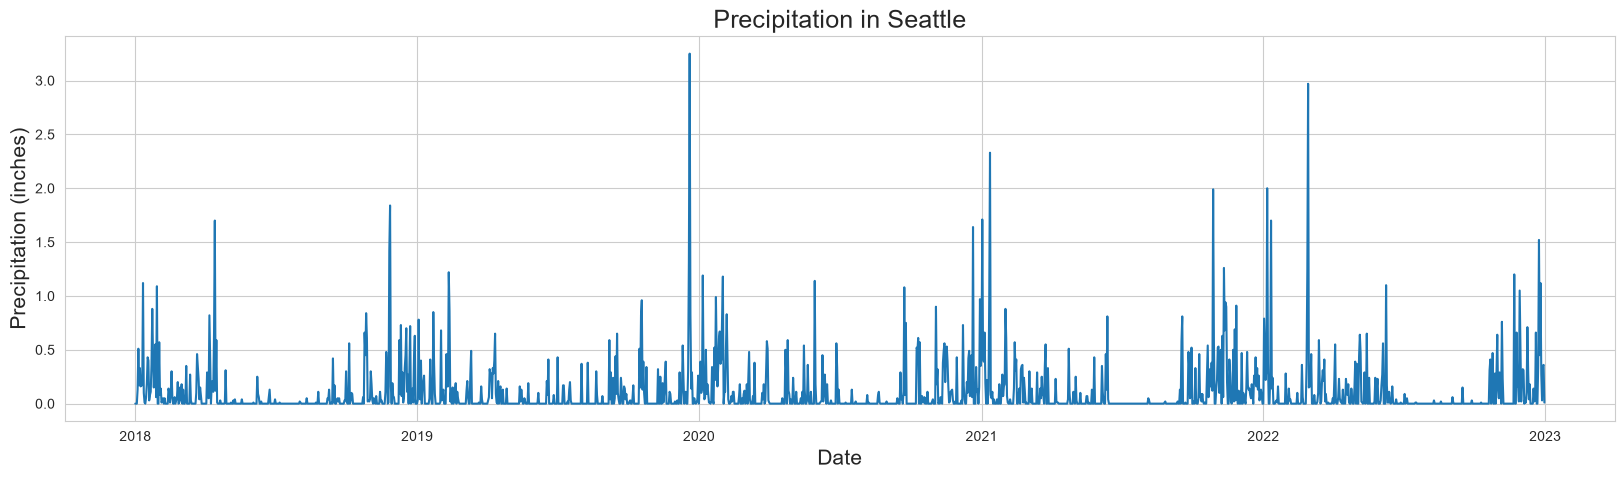

In [21]:
plt.figure(figsize=(20,5))
plt.title("Precipitation in Seattle", fontsize = 18)
sns.lineplot(data = df_sea, x = "DATE", y = "PRCP")
plt.xlabel("Date", fontsize = 15)
plt.ylabel("Precipitation (inches)", fontsize = 15)
plt.show()

Initial impression: Seattle’s precipitation appears to show a seasonal pattern. There are periods with consistently higher precipitation and other periods with noticeably lower precipitation. A small number of days also show unusually high precipitation amounts compared with the rest of the observations.

### Plot Precipitation data for Charlotte

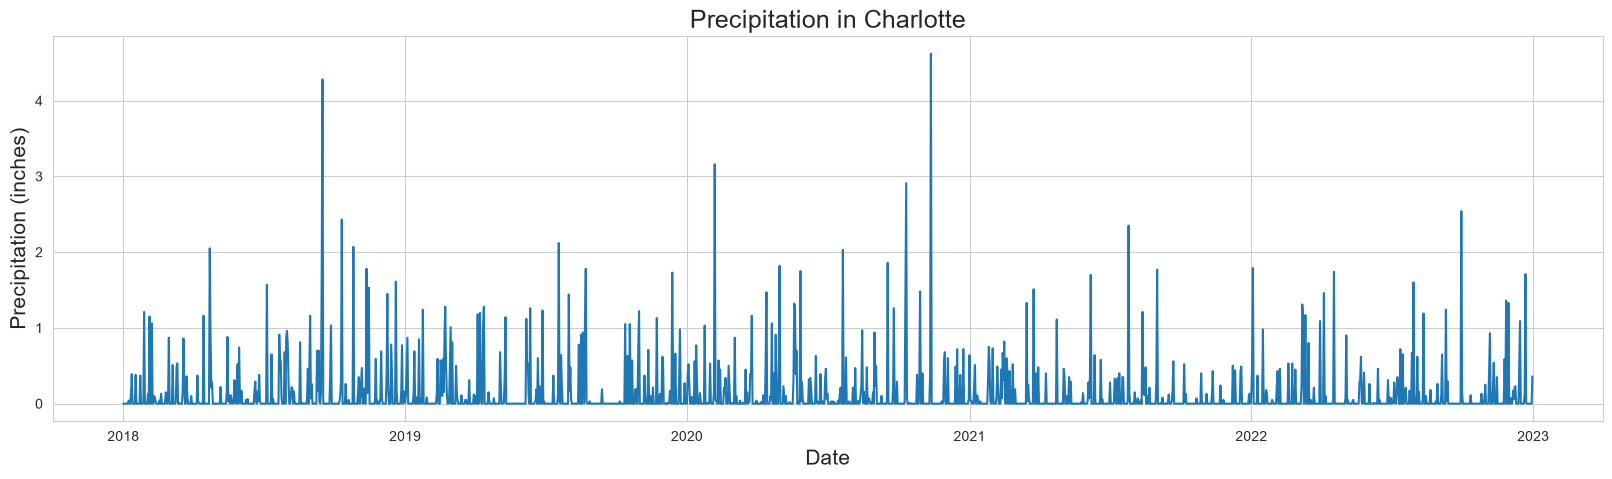

In [22]:
plt.figure(figsize=(20,5))
plt.title("Precipitation in Charlotte", fontsize = 18)
sns.lineplot(data = df_cha, x = "DATE", y = "PRCP")
plt.xlabel("Date", fontsize = 15)
plt.ylabel("Precipitation (inches)", fontsize = 15)
plt.show()

Initial impression: Charlotte’s daily precipitation does not show as clear a seasonal pattern as Seattle’s. Precipitation appears more evenly distributed throughout the year, although there are several unusually high-precipitation days. Because relatively high rainfall occurs throughout the dataset, these extreme values stand out less than they do in Seattle.

## Review Summary Statistics

We expect the dataset to be heavily influenced by zero(0) since there should be a signinifcant number of days with no precipitation

In [23]:
df_sea.describe()

,DATE,PRCP
count,1826,1823.000000
mean,2020-07-01 12:00:00,0.107071
min,2018-01-01 00:00:00,0.000000
25%,2019-04-02 06:00:00,0.000000
50%,2020-07-01 12:00:00,0.000000
75%,2021-09-30 18:00:00,0.100000
max,2022-12-31 00:00:00,3.250000
std,NaN,0.252325


In [24]:
df_cha.describe()

,DATE,PRCP
count,1826,1826.000000
mean,2020-07-01 12:00:00,0.138001
min,2018-01-01 00:00:00,0.000000
25%,2019-04-02 06:00:00,0.000000
50%,2020-07-01 12:00:00,0.000000
75%,2021-09-30 18:00:00,0.060000
max,2022-12-31 00:00:00,4.620000
std,NaN,0.365697


## Merge two dataframes 

In [25]:
df = pd.merge(df_sea, df_cha, on= "DATE", how = "outer")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   STATION_x  1826 non-null   str           
 1   DATE       1826 non-null   datetime64[us]
 2   PRCP_x     1823 non-null   float64       
 3   STATION_y  1826 non-null   str           
 4   PRCP_y     1826 non-null   float64       
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 110.7 KB


### Drop redundant columns. 
After Merge, we don not need station infomation. 


In [26]:
df.drop(columns=['STATION_x','STATION_y'], inplace = True) 

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    1826 non-null   datetime64[us]
 1   PRCP_x  1823 non-null   float64       
 2   PRCP_y  1826 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 42.9 KB


In [28]:
df.head(10)


,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.13,0.00
4,2018-01-05,0.51,0.00
5,2018-01-06,0.17,0.00
6,2018-01-07,0.33,0.00
7,2018-01-08,0.16,0.04
8,2018-01-09,0.18,0.00
9,2018-01-10,0.17,0.00


We now have date in one column, precipitation data for Seattle labeled (PRCP_x) and precipitation data for Charlotte labeled (PRCP_y)

### Rename Columns

In [29]:
df.rename(columns={"PRCP_x": "Seattle",
    "PRCP_y": "Charlotte"
}, inplace = True)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DATE       1826 non-null   datetime64[us]
 1   Seattle    1823 non-null   float64       
 2   Charlotte  1826 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 42.9 KB


### Handle missing values

We will be imputing missing precipitation data based on daily mean value. 

In [31]:
df[df["Seattle"].isna()]

,DATE,Seattle,Charlotte
1447,2021-12-18,NaN,0.43
1457,2021-12-28,NaN,0.00
1459,2021-12-30,NaN,0.13


We are missing three days in december of 2021

In [32]:
seattle_daily_mean = df.groupby([df['DATE'].dt.month, df['DATE'].dt.day])['Seattle'].transform('mean')
seattle_daily_mean

0       0.0840
1       0.5500
2       0.4200
3       0.1840
4       0.3360
         ...  
1821    0.0900
1822    0.1150
1823    0.2560
1824    0.3425
1825    0.1240
Name: Seattle, Length: 1826, dtype: float64

Impute value using the calculated daily mean. 

In [33]:
df['Seattle'] = df['Seattle'].fillna(seattle_daily_mean)

In [34]:
df.loc[[1447,1457,1459]]

,DATE,Seattle,Charlotte
1447,2021-12-18,0.3025,0.43
1457,2021-12-28,0.1150,0.00
1459,2021-12-30,0.3425,0.13


Let us verify if the calculation is correct for sanity check

In [35]:
df_sea[
    (df_sea["DATE"].dt.month == 12) &
    (df_sea["DATE"].dt.day == 18)
]

,STATION,DATE,PRCP
351,USW00024233,2018-12-18,0.70
716,USW00024233,2019-12-18,0.30
1082,USW00024233,2020-12-18,0.19
1447,USW00024233,2021-12-18,NaN
1812,USW00024233,2022-12-18,0.02


In [36]:
df_sea.loc[
    (df_sea["DATE"].dt.month == 12) &
    (df_sea["DATE"].dt.day == 18),
    "PRCP"
].mean()

np.float64(0.3025)

In [37]:
df.loc[df['DATE']=='2021-12-18']

,DATE,Seattle,Charlotte
1447,2021-12-18,0.3025,0.43


## Convert the df to tidy format 
Using pd.melt(), This will transpose the city column into rows.


In [38]:
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [39]:
df

,DATE,city,precipitation
0,2018-01-01,Seattle,0.00
1,2018-01-02,Seattle,0.00
2,2018-01-03,Seattle,0.00
3,2018-01-04,Seattle,0.13
4,2018-01-05,Seattle,0.51
...,...,...,...
3647,2022-12-27,Charlotte,0.00
3648,2022-12-28,Charlotte,0.00
3649,2022-12-29,Charlotte,0.00
3650,2022-12-30,Charlotte,0.00


In [40]:
df.rename(columns={'DATE':'date'}, inplace = True)

Export/Save clean dataset 

Get current Directory

In [41]:
import os
print(os.getcwd())

C:\Users\binay\Documents\data5100\projects\weather\code


In [42]:
df.to_csv('../data/clean_seattle_charlotte_weather.csv', encoding='utf-8-sig', index=False) # go back one directory then save file in the 'data' folder

In [43]:
df.head()

,date,city,precipitation
0,2018-01-01,Seattle,0.00
1,2018-01-02,Seattle,0.00
2,2018-01-03,Seattle,0.00
3,2018-01-04,Seattle,0.13
4,2018-01-05,Seattle,0.51


### Set color pallete for the two cities


In [44]:
city_colors = {
    "Seattle": "blue",
    "Charlotte": "orange"
}

### Create a line plots to look at daily rainfall for both cities

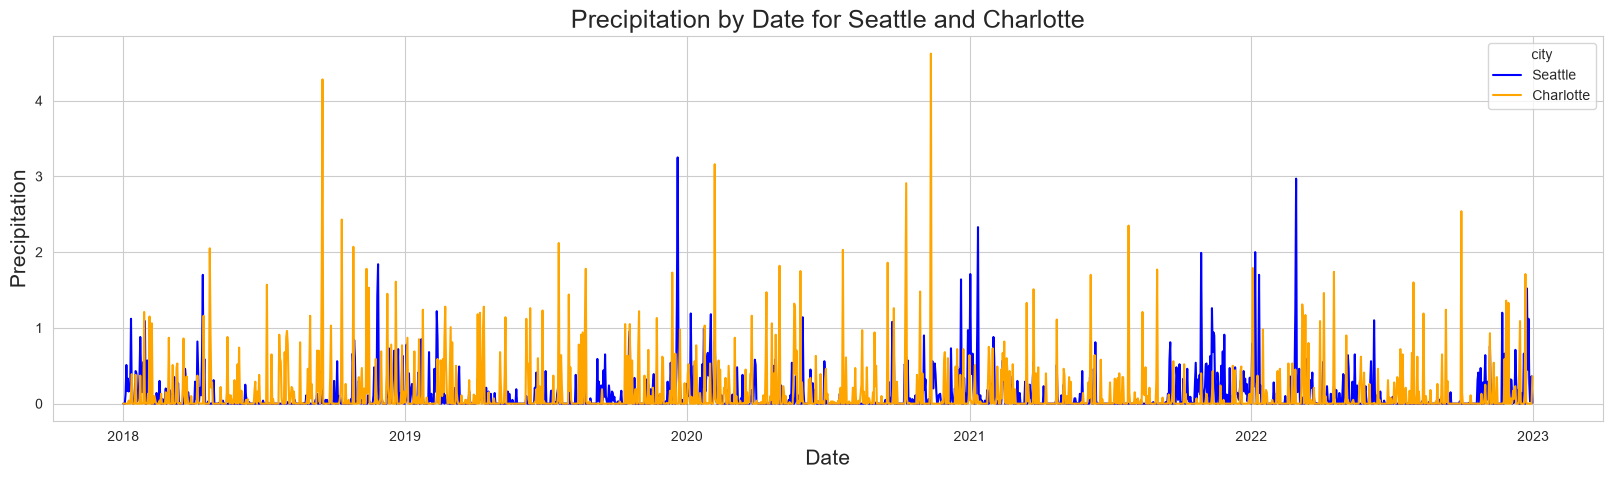

In [45]:
plt.figure(figsize = (20,5))
sns.lineplot(data= df, x = 'date', y = 'precipitation', hue = 'city', palette = city_colors)
plt.title("Precipitation by Date for Seattle and Charlotte",  fontsize = 18)
plt.xlabel("Date",  fontsize = 15)
plt.ylabel("Precipitation",  fontsize = 15)
plt.show()


Across the full 5-year period, which city had the higher mean daily precipitation?

Text(0, 0.5, 'Mean Precipitation')

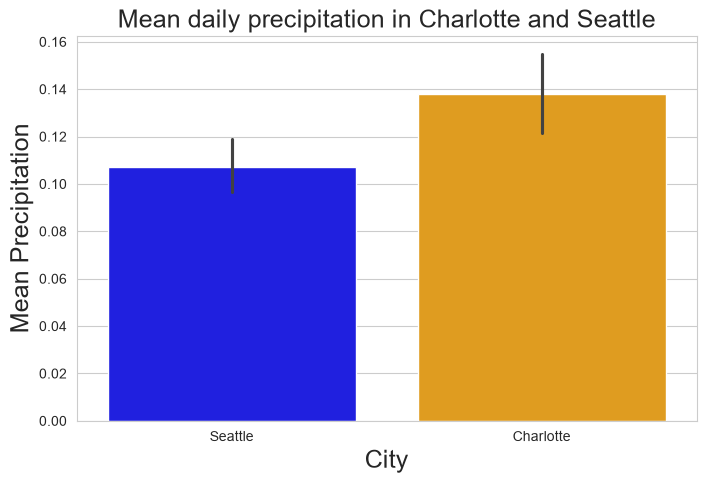

In [46]:
plt.figure(figsize = (8,5))

sns.barplot(data = df, x = 'city', y = 'precipitation', hue = 'city', palette = city_colors)

plt.title("Mean daily precipitation in Charlotte and Seattle",  fontsize = 18)
plt.xlabel("City",  fontsize = 18)
plt.ylabel("Mean Precipitation",  fontsize = 18)

Based on the above chart, Charlotte edges seattle on daily mean precipitation. 

## Breakdown of precipitation by month

In [47]:
# Add day of year column
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year
df

,date,city,precipitation,day_of_year
0,2018-01-01,Seattle,0.00,1
1,2018-01-02,Seattle,0.00,2
2,2018-01-03,Seattle,0.00,3
3,2018-01-04,Seattle,0.13,4
4,2018-01-05,Seattle,0.51,5
...,...,...,...,...
3647,2022-12-27,Charlotte,0.00,361
3648,2022-12-28,Charlotte,0.00,362
3649,2022-12-29,Charlotte,0.00,363
3650,2022-12-30,Charlotte,0.00,364


In [48]:
# Add month 
df['month'] = pd.DatetimeIndex(df['date']).month # This will result in months being labeled numerically 
# df['month'] = df['date'].dt.month_name() # alternate approach to include month name
df

,date,city,precipitation,day_of_year,month
0,2018-01-01,Seattle,0.00,1,1
1,2018-01-02,Seattle,0.00,2,1
2,2018-01-03,Seattle,0.00,3,1
3,2018-01-04,Seattle,0.13,4,1
4,2018-01-05,Seattle,0.51,5,1
...,...,...,...,...,...
3647,2022-12-27,Charlotte,0.00,361,12
3648,2022-12-28,Charlotte,0.00,362,12
3649,2022-12-29,Charlotte,0.00,363,12
3650,2022-12-30,Charlotte,0.00,364,12


### Boxplot to visualize monthly precipitation for both cities

In [49]:
# df['date'].dt.month_name() 

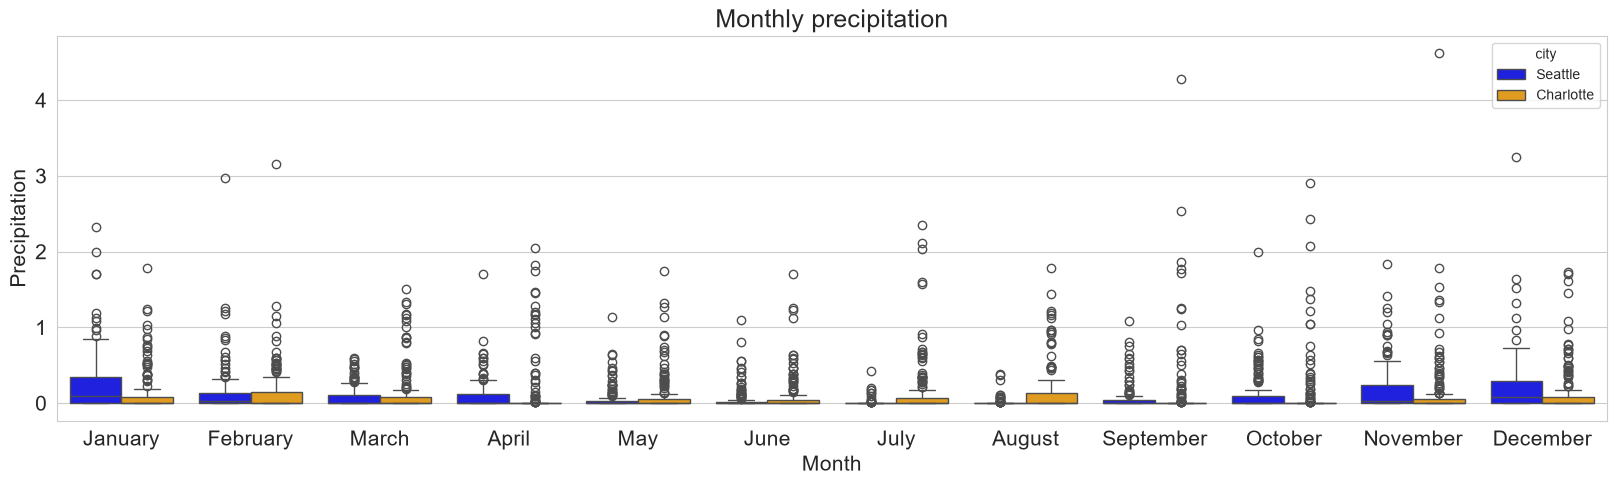

In [50]:
plt.figure(figsize =(20,5))
sns.boxplot(data = df, x = 'month', y = 'precipitation', hue = 'city', palette = city_colors)
plt.title("Monthly precipitation", fontsize = 18)
plt.xlabel("Month",  fontsize = 15)
plt.ylabel("Precipitation",  fontsize = 15)
plt.tick_params(labelsize =15)

# Get month names and set x=axis tick labels
import calendar
month_names = list(calendar.month_name[1:]) # retreive moonth names
plt.xticks(ticks= range(12), labels = month_names)
plt.show()

Reorienting the plot such that month is in y axis and precipitation on x axis

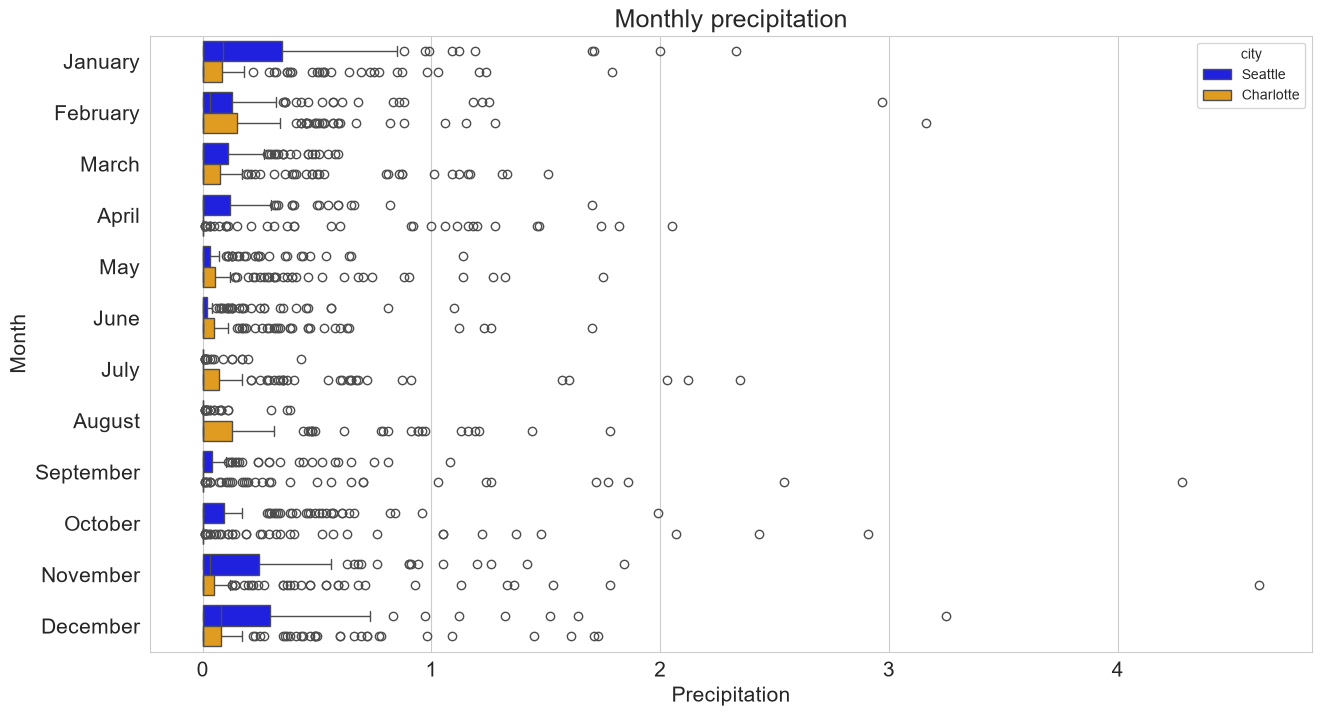

In [51]:
plt.figure(figsize =(15,8))
sns.boxplot(data = df, x = 'precipitation', y = 'month', hue = 'city', palette = city_colors, orient='h')
plt.title("Monthly precipitation", fontsize = 18)
plt.xlabel("Precipitation",  fontsize = 15)
plt.ylabel("Month",  fontsize = 15)
plt.tick_params(labelsize =15)

plt.yticks(ticks= range(12), labels = month_names)
plt.show()

The boxplots show several extreme precipitation outliers for Charlotte, with some daily rainfall values much higher than the rest of the distribution.

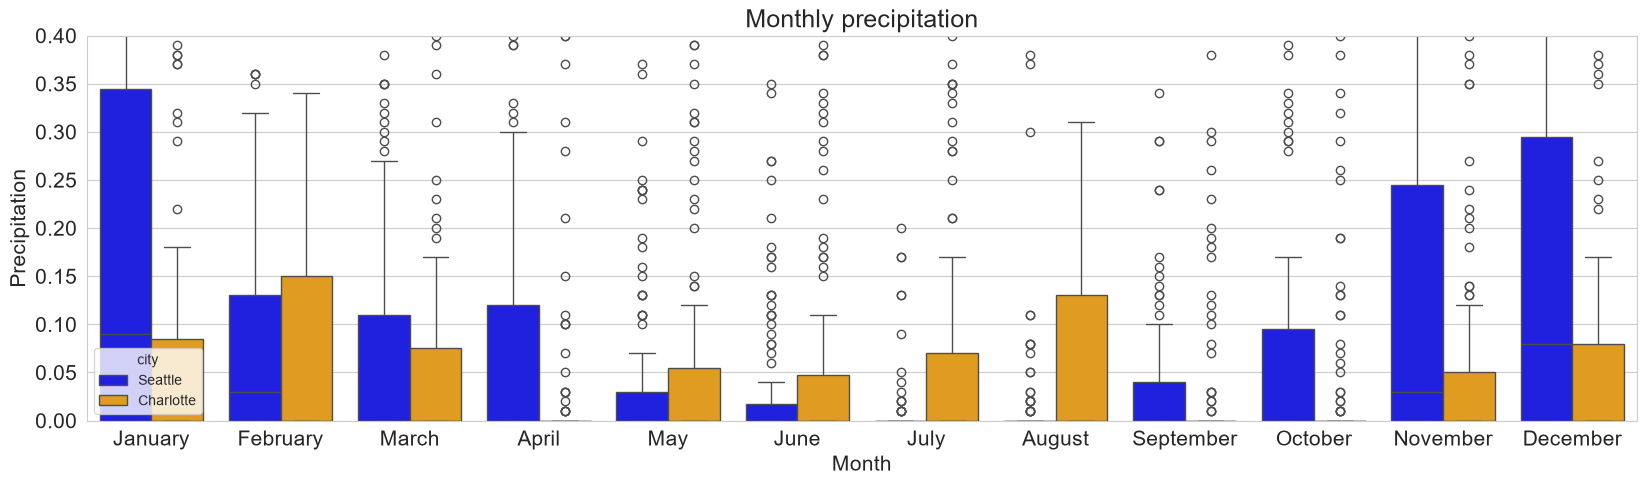

In [52]:
plt.figure(figsize =(20,5))
sns.boxplot(data = df, x = 'month', y = 'precipitation', hue = 'city', palette = city_colors)
plt.title("Monthly precipitation", fontsize = 18)
plt.xlabel("Month",  fontsize = 15)
plt.ylabel("Precipitation",  fontsize = 15)
plt.ylim(0, 0.4)

plt.tick_params(labelsize =15)


plt.xticks(ticks= range(12), labels = month_names)
plt.show()

### Barplot to visualize mean precipitation. 

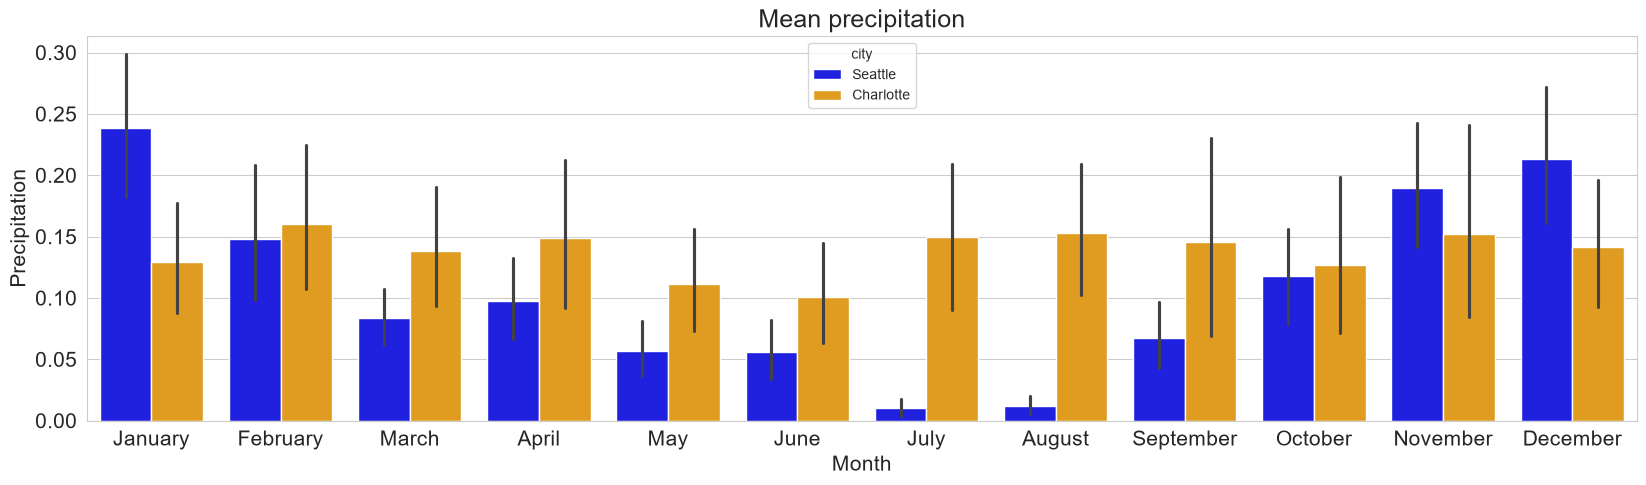

In [53]:
plt.figure(figsize =(20,5))
sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city', palette = city_colors)
plt.title("Mean precipitation", fontsize = 18)
plt.xlabel("Month", fontsize = 15)
plt.ylabel("Precipitation",  fontsize = 15)

plt.tick_params(labelsize =15)


plt.xticks(ticks= range(12), labels = month_names)
plt.show()

The chart shows that Seattle receives more precipitation during the winter months and much less during the summer, indicating a clear seasonal pattern. In contrast, Charlotte’s mean precipitation appears more consistent throughout the year, with less pronounced seasonal variation.

In [54]:
df[['month', 'precipitation', 'city']].groupby(['city', 'month']).mean()

precipitation
city      month               
Charlotte 1           0.129613
          2           0.160426
          3           0.138516
          4           0.148800
          5           0.110968
          6           0.101133
          7           0.149742
          8           0.152581
          9           0.145200
          10          0.127097
          11          0.152000
          12          0.141806
Seattle   1           0.238645
          2           0.147730
          3           0.083290
          4           0.097733
          5           0.056774
          6           0.055933
          7           0.010000
          8           0.012065
          9           0.067400
          10          0.118065
          11          0.189733
          12          0.213419

### Review days with rainfall/Proportions

Add a new column that lets us know weather any precipitation occured on the specific day. After that we will create a bar plot to see average number of days it rained in a month.

In [55]:
df['any_precipitation'] = df['precipitation'] > 0
df

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,Seattle,0.00,1,1,False
1,2018-01-02,Seattle,0.00,2,1,False
2,2018-01-03,Seattle,0.00,3,1,False
3,2018-01-04,Seattle,0.13,4,1,True
4,2018-01-05,Seattle,0.51,5,1,True
...,...,...,...,...,...,...
3647,2022-12-27,Charlotte,0.00,361,12,False
3648,2022-12-28,Charlotte,0.00,362,12,False
3649,2022-12-29,Charlotte,0.00,363,12,False
3650,2022-12-30,Charlotte,0.00,364,12,False


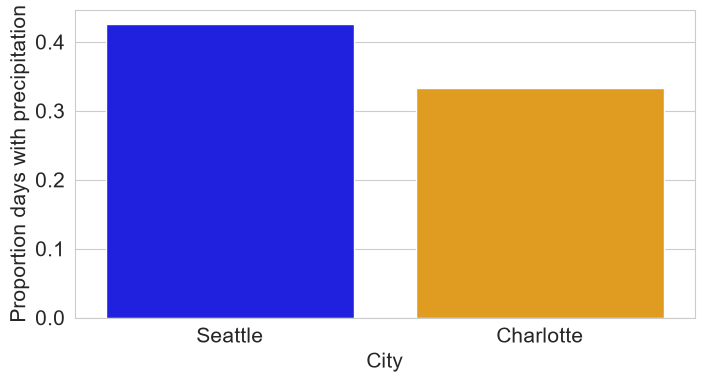

In [56]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='city', y='any_precipitation', errorbar = None, hue = 'city', palette = city_colors)

plt.xlabel('City', fontsize=15)
plt.ylabel('Proportion days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

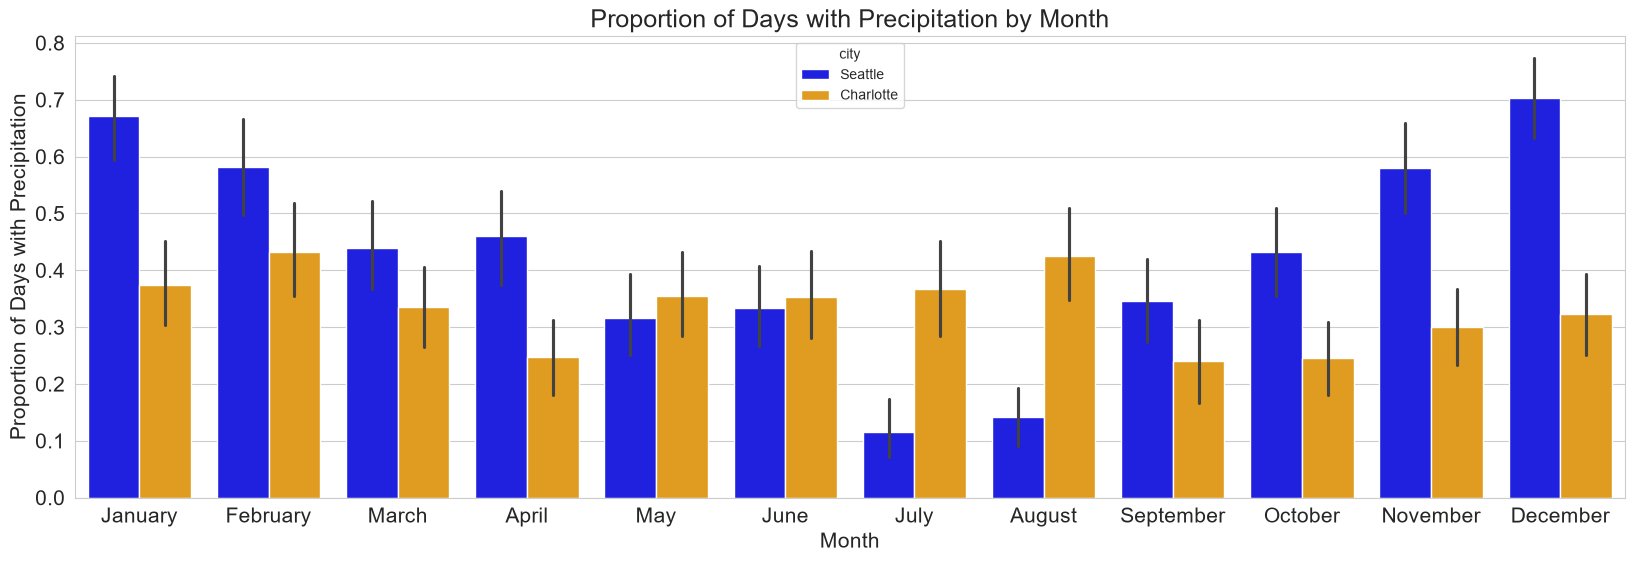

In [57]:
plt.figure(figsize =(20,6))
sns.barplot(data = df, x = 'month', y = 'any_precipitation',  hue = 'city', palette = city_colors)
plt.title("Proportion of Days with Precipitation by Month", fontsize = 18)
plt.xlabel("Month", fontsize = 15)
plt.ylabel("Proportion of Days with Precipitation", fontsize = 15)


plt.tick_params(labelsize =15)


plt.xticks(ticks= range(12), labels = month_names)
plt.show()

This chart shows that Seattle has a higher proportion of rainy days during most months, especially in the fall and winter. Charlotte has fewer rainy days in many months, but earlier results showed higher mean precipitation in several months. This suggests that Seattle tends to experience precipitation more frequently, while Charlotte may receive more precipitation when rain does occur.

## Data with Precipitation only

In [58]:
df_rainy_days = df[df["precipitation"] > 0]

df_rainy_days.groupby(
    ["city", "month"]
)["precipitation"].agg(
    ["mean", "median", "count"]
)

mean  median  count
city      month                         
Charlotte 1      0.346379   0.165     58
          2      0.370820   0.240     61
          3      0.412885   0.220     52
          4      0.603243   0.370     37
          5      0.312727   0.150     55
          6      0.286226   0.170     53
          7      0.407193   0.210     57
          8      0.358333   0.165     66
          9      0.605000   0.215     36
          10     0.518421   0.220     38
          11     0.506667   0.270     45
          12     0.439600   0.355     50
Seattle   1      0.355673   0.205    104
          2      0.254024   0.110     82
          3      0.189853   0.150     68
          4      0.212464   0.130     69
          5      0.179592   0.110     49
          6      0.167800   0.095     50
          7      0.086111   0.035     18
          8      0.085000   0.040     22
          9      0.194423   0.085     52
          10     0.273134   0.130     67
          11     0.327126   0.190     87
          12     0.303486   0.170    109

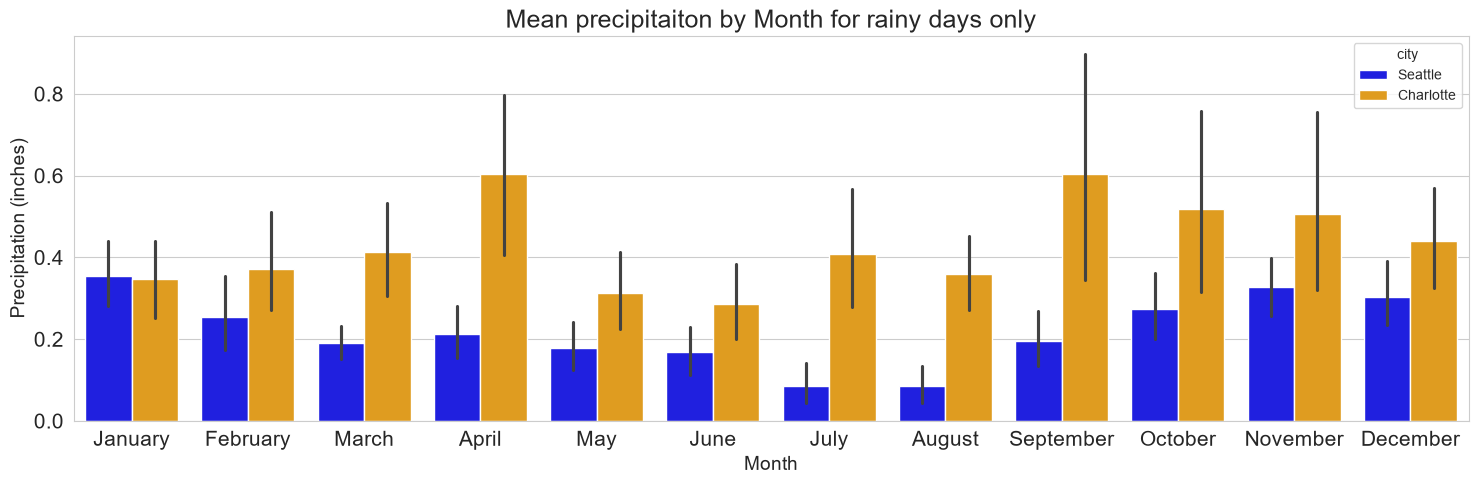

In [59]:
plt.figure(figsize = (18,5))
sns.barplot(data = df_rainy_days, x = 'month', y = 'precipitation', hue = 'city', palette = city_colors, hue_order=["Seattle", "Charlotte"])
plt.title("Mean precipitaiton by Month for rainy days only", fontsize = 18)
plt.xlabel("Month", fontsize =14)
plt.ylabel("Precipitation (inches)", fontsize = 14)

plt.tick_params(labelsize =15)
plt.xticks(ticks= range(12), labels = month_names)

plt.show()

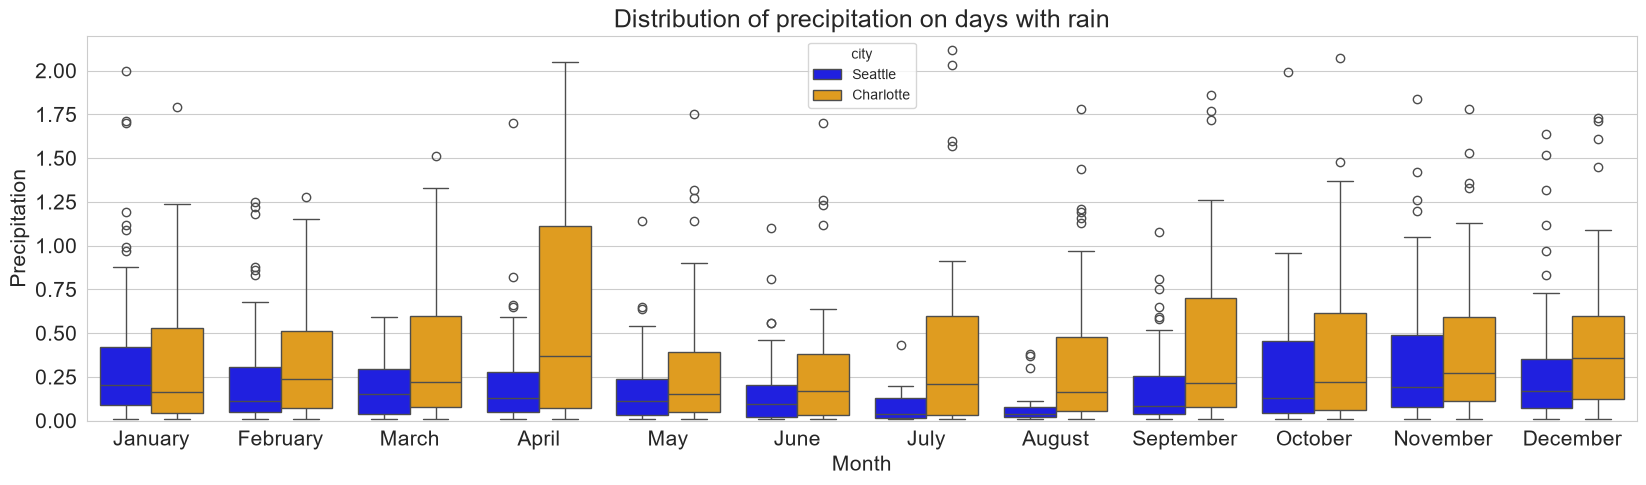

In [60]:
plt.figure(figsize = (20,5))

sns.boxplot(data = df_rainy_days , x = 'month', y = 'precipitation', hue = 'city', palette = city_colors, hue_order =['Seattle','Charlotte'])

plt.title("Distribution of precipitation on days with rain", fontsize =18)
plt.xlabel("Month", fontsize = 15)
plt.ylabel("Precipitation", fontsize = 15)
plt.ylim(0, 2.2)

plt.tick_params(labelsize =15)

plt.xticks(ticks= range(12), labels = month_names)
plt.show()

The boxplot shows that Charlotte generally has higher precipitation amounts on rainy days than Seattle, particularly during several spring, summer, and fall months. Seattle appears to experience more frequent rainy days, while Charlotte tends to receive heavier precipitation when rain occurs. The distributions also contain several high-precipitation outliers, especially for Charlotte.

### Statistical Analysis


#### Perform a statistical test for differences in the mean precipitation each month between the cities

$$H_0: \mu_{\text{Seattle, January}} = \mu_{\text{Charlotte, January}}$$
$$H_a: \mu_{\text{Seattle, January}} \neq \mu_{\text{Charlotte, January}}$$

$$\vdots$$

$$H_0: \mu_{\text{Seattle, December}} = \mu_{\text{Charlotte, December}}$$
$$H_a: \mu_{\text{Seattle, December}} \neq \mu_{\text{Charlotte, December}}$$

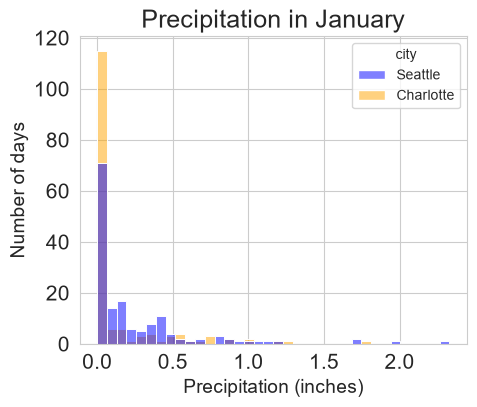

In [61]:
plt.figure(figsize = (5,4))
sns.histplot(data = df.loc[df['month'] ==1], x = 'precipitation', hue = 'city', palette = city_colors)

plt.xlabel('Precipitation (inches)', fontsize =14)
plt.ylabel('Number of days', fontsize = 14)
plt.title('Precipitation in January', fontsize = 18)
plt.tick_params(labelsize = 15)
plt.show()

The distribution in the histogram plot is not normal and therefore it doesn't satisfy the underlying assumption to perform t-test. However, since we have a large sample data, we can proceed with the test

### Two Sample t-test on sample mean

In [62]:
from scipy import stats


In [63]:
significance_level = 0.05
significantly_different = np.zeros(12)

# Perform t-test for each month
for month in range(1,13):
    # Get precipitaiton data for Seattle and Charlotte for the current month
    sea_data = df.loc[(df['city'] == 'Seattle') & (df['month'] == month), 'precipitation']
    cha_data = df.loc[(df['city'] == 'Charlotte') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, cha_data, equal_var = False)

    if p_value < significance_level:
        significantly_different[month-1] = 1

    print(f"Month {month}:")
    print(f" t-statistic = {t_statistic:.2f}")
    print(f" p-value t test = {p_value:.3f}")
    print("-"*20)

Month 1:
 t-statistic = 2.84
 p-value t test = 0.005
--------------------
Month 2:
 t-statistic = -0.31
 p-value t test = 0.761
--------------------
Month 3:
 t-statistic = -2.00
 p-value t test = 0.047
--------------------
Month 4:
 t-statistic = -1.39
 p-value t test = 0.166
--------------------
Month 5:
 t-statistic = -2.18
 p-value t test = 0.030
--------------------
Month 6:
 t-statistic = -1.88
 p-value t test = 0.061
--------------------
Month 7:
 t-statistic = -4.52
 p-value t test = 0.000
--------------------
Month 8:
 t-statistic = -5.32
 p-value t test = 0.000
--------------------
Month 9:
 t-statistic = -1.79
 p-value t test = 0.075
--------------------
Month 10:
 t-statistic = -0.23
 p-value t test = 0.817
--------------------
Month 11:
 t-statistic = 0.81
 p-value t test = 0.418
--------------------
Month 12:
 t-statistic = 1.79
 p-value t test = 0.074
--------------------


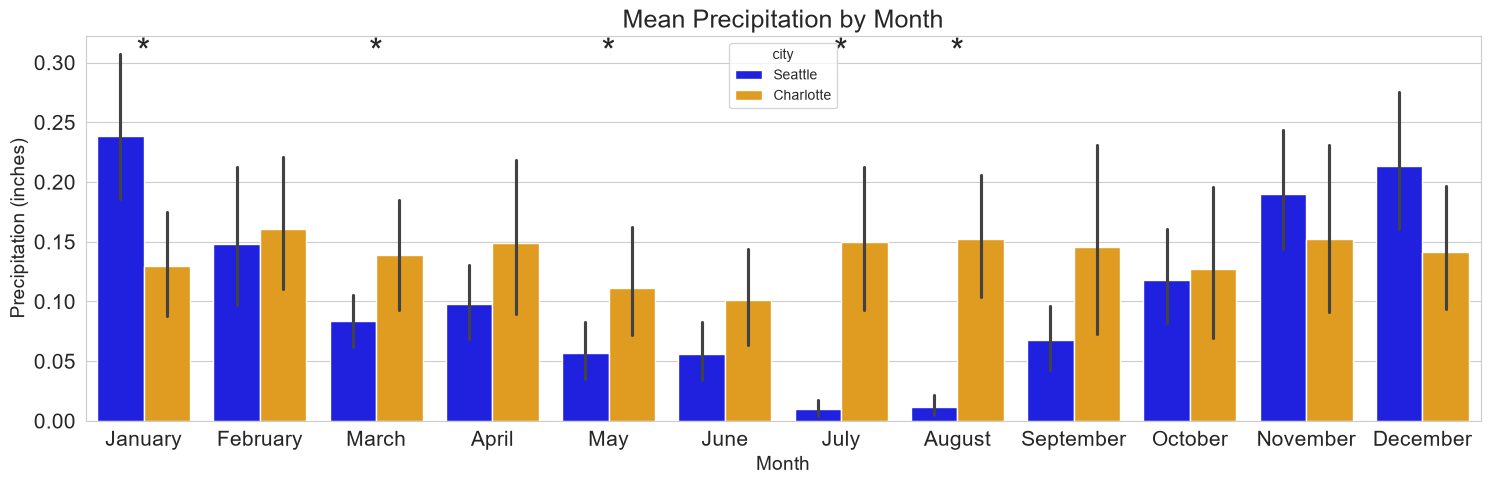

In [64]:
plt.figure(figsize = (18,5))
sns.barplot(data = df, x = 'month', y = 'precipitation', hue = 'city', palette = city_colors, hue_order=["Seattle", "Charlotte"])
plt.title("Mean Precipitation by Month", fontsize = 18)
plt.xlabel("Month", fontsize =14)
plt.ylabel("Precipitation (inches)", fontsize = 14)

plt.tick_params(labelsize =15)
plt.xticks(ticks= range(12), labels = month_names)

# Add stars for significantly different months
for month in range(12):
    # Add a star
    if significantly_different[month] == 1:
        plt.text(month, 0.3, '*', ha = 'center', fontsize =25)
    
plt.show()

The differences in mean precipitation between Seattle and Charlotte were statistically significant in January, March, May, July, and August. Therefore, for those months, we reject the null hypothesis. For February, April, June, September, October, November, and December, we fail to reject the null hypothesis because there was insufficient evidence of a difference in mean precipitation.

### Proportions ztest on proportions


#### Perform a statistical test for differences in the proportion of days with any precipitation each month between the cities

$$H_0: p_{\text{Seattle, January}} = p_{\text{Charlotte, January}}$$
$$H_a: p_{\text{Seattle, January}} \neq p_{\text{Charlotte, January}}$$

$$\vdots$$

$$H_0: p_{\text{Seattle, December}} = p_{\text{Charlotte, December}}$$
$$H_a: p_{\text{Seattle, December}} \neq p_{\text{Charlotte, December}}$$

In [65]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

# Perform two-proportion z-test for each month
for month in range(1,13):
    # Create a contingency table for Seattle and Charlotte for the current month
    contingency_table = pd.crosstab(df.loc[df['month'] == month, 'city'], df.loc[df['month'] == month, 'any_precipitation'])
    
    # Calculate the number of True values (days with precipitation) for each city
    days_with_precipitation = contingency_table[True]

    # Calculate the total nimber of days for each city
    total_counts = contingency_table.sum(axis =1)

    # hypothesis test
    zstat, p_value = proportions_ztest(count = days_with_precipitation, nobs = total_counts, alternative= 'two-sided')

    if p_value < significance_level:
        significantly_different_proportion[month-1] = 1

    print(f"Month {month}:")
    print(f" z-statistic = {zstat:.2f}")
    print(f" p-value = {p_value:.3f}")
    print("-"*20)

Month 1:
 z-statistic = -5.23
 p-value = 0.000
--------------------
Month 2:
 z-statistic = -2.50
 p-value = 0.012
--------------------
Month 3:
 z-statistic = -1.87
 p-value = 0.062
--------------------
Month 4:
 z-statistic = -3.87
 p-value = 0.000
--------------------
Month 5:
 z-statistic = 0.72
 p-value = 0.470
--------------------
Month 6:
 z-statistic = 0.36
 p-value = 0.715
--------------------
Month 7:
 z-statistic = 5.17
 p-value = 0.000
--------------------
Month 8:
 z-statistic = 5.54
 p-value = 0.000
--------------------
Month 9:
 z-statistic = -2.03
 p-value = 0.042
--------------------
Month 10:
 z-statistic = -3.48
 p-value = 0.001
--------------------
Month 11:
 z-statistic = -4.89
 p-value = 0.000
--------------------
Month 12:
 z-statistic = -6.70
 p-value = 0.000
--------------------


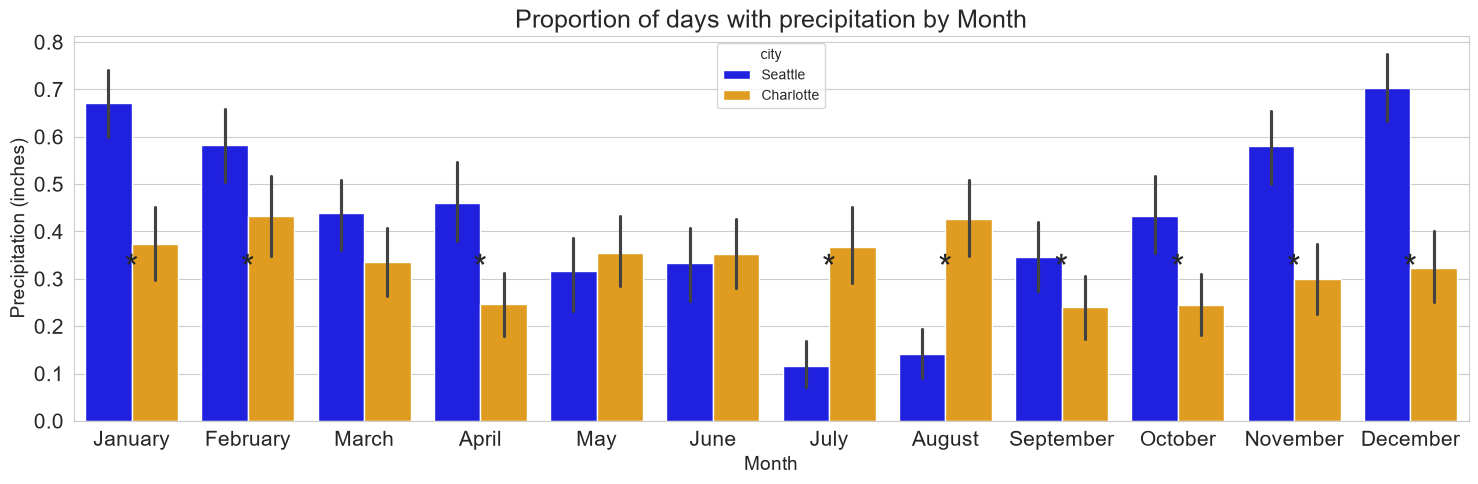

In [66]:
plt.figure(figsize = (18,5))
sns.barplot(data = df, x = 'month', y = 'any_precipitation', hue = 'city', palette = city_colors, hue_order=["Seattle", "Charlotte"])
plt.title("Proportion of days with precipitation by Month", fontsize = 18)
plt.xlabel("Month", fontsize =14)
plt.ylabel("Precipitation (inches)", fontsize = 14)

plt.tick_params(labelsize =15)
plt.xticks(ticks= range(12), labels = month_names)

# Add stars for significantly different months
for month in range(12):
    # Add a star
    if significantly_different_proportion[month] == 1:
        plt.text(month, 0.3, '*', ha = 'center', fontsize =25)
    
plt.show()

The proportion of days with precipitation differed significantly between Seattle and Charlotte in January, February, April, July, August, September, October, November, and December. For these months, we reject the null hypothesis that the proportion of days with precipitation is equal between the two cities. For March, May, and June, we fail to reject the null hypothesis because there is insufficient evidence to conclude that the proportions differ.

### Contengency table 


In [67]:
contingency_table = pd.crosstab(df.loc[df['month'] ==1, 'city'], df.loc[df['month'] == 1, 'any_precipitation'])
contingency_table

any_precipitation,False,True
city,,
Charlotte,97,58
Seattle,51,104


The contengency table shows 104 days of precipitation in Seattle for the month of January compared to 58 days in Charlotte.

Overall, Charlotte has higher overall mean daily precipitation compared to Seattle. There is a significant seasonal differences in precipitation in Seattle and Charlotte. Seattle experiences a wet and dry seasonal pattern, with fall, winter, and spring months experiencing majority of precipitation. Charlotte however, experiences a more consistent rainfall pattern with no real dry season. Seattle also experiences precipitation a greater proportions of days. Despite the proportions, overall volume is till higher in Charlotte, which means charlotte receives more precipitation on days with precipitation.  